Install Packages

In [ ]:
!pip install -q transformers datasets evaluate accelerate sacrebleu


Mount google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imports and helpers

In [ ]:
import math
import os
import random
import json
from collections import defaultdict
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
import evaluate
from sacrebleu import BLEU

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    get_linear_schedule_with_warmup,
)
from transformers.pytorch_utils import Conv1D
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


def _safe(s: str) -> str:
    return ''.join(c if (c.isalnum() or c in ['-', '_', '.']) else '-' for c in str(s))


def save_run_metrics(
    *,
    dataset: str,
    model_tag: str,
    train_losses: list,
    eval_bleu: list,
    batch_size: int,
    learning_rate: float,
    num_epochs: int,
    model_name: str,
    lora_r: int | None = None,
    lora_alpha: int | None = None,
) -> str:
    """Persist a single rank-sweep run to results/ as JSON."""
    results_dir = Path("results")
    results_dir.mkdir(parents=True, exist_ok=True)

    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    parts = [
        _safe(dataset),
        _safe(model_tag),
        _safe(model_name),
        f"bs{batch_size}",
        f"lr{learning_rate:g}",
        f"ep{num_epochs}",
    ]
    if lora_r is not None:
        parts.append(f"r{lora_r}")
    if lora_alpha is not None:
        parts.append(f"a{lora_alpha}")
    parts.append(ts)

    out_path = results_dir / ("__".join(parts) + ".json")

    payload = {
        "dataset": dataset,
        "model_tag": model_tag,
        "model_name": model_name,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "num_epochs": num_epochs,
        "lora_r": lora_r,
        "lora_alpha": lora_alpha,
        "train_loss_by_epoch": train_losses,
        "eval_bleu_by_epoch": eval_bleu,
        "saved_at": ts,
    }

    out_path.write_text(json.dumps(payload, indent=2) + "\n")
    return str(out_path)



Set Seed

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


Load E2E NLG dataset

In [ ]:
data_files = {
    "train": "https://github.com/tuetschek/e2e-dataset/raw/master/trainset.csv",
    "validation": "https://github.com/tuetschek/e2e-dataset/raw/master/devset.csv",
}
e2e_dataset = load_dataset("csv", data_files=data_files)
print(e2e_dataset)
print(e2e_dataset["train"][0])


DatasetDict({
    train: Dataset({
        features: ['mr', 'ref'],
        num_rows: 42061
    })
    validation: Dataset({
        features: ['mr', 'ref'],
        num_rows: 4672
    })
})
{'mr': 'name[The Vaults], eatType[pub], priceRange[more than £30], customer rating[5 out of 5], near[Café Adriatic]', 'ref': 'The Vaults pub near Café Adriatic has a 5 star rating.  Prices start at £30.'}


Load GPT-2 tokenizer

In [ ]:
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token


Tokenize dataset for causal LM

In [ ]:
max_seq_length = 128

def tokenize_e2e(examples):
    inputs = [
        f"{mr} => {ref}{tokenizer.eos_token}"
        for mr, ref in zip(examples["mr"], examples["ref"])
    ]
    tokenized = tokenizer(
        inputs,
        truncation=True,
        padding="max_length",
        max_length=max_seq_length,
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

tokenized_e2e = e2e_dataset.map(tokenize_e2e, batched=True)
tokenized_e2e = tokenized_e2e.remove_columns(["mr", "ref"])
tokenized_e2e.set_format("torch")

print(tokenized_e2e)


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 42061
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 4672
    })
})


Build dataloaders

In [ ]:
train_batch_size = 8
eval_batch_size = 8

train_dataloader = DataLoader(
    tokenized_e2e["train"],
    shuffle=True,
    batch_size=train_batch_size,
)

eval_dataloader = DataLoader(
    tokenized_e2e["validation"],
    shuffle=False,
    batch_size=eval_batch_size,
)

print("train batches:", len(train_dataloader))
print("eval batches: ", len(eval_dataloader))


train batches: 5258
eval batches:  584


Load baseline GPT-2 model first

In [ ]:
model = AutoModelForCausalLM.from_pretrained(model_name)
model.to(device)
print(type(model))


GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'>


Inspect GPT-2 attention module names

In [ ]:
for name, module in model.named_modules():
    if "attn" in name and isinstance(module, Conv1D):
        print(name, tuple(module.weight.shape))


transformer.h.0.attn.c_attn (768, 2304)
transformer.h.0.attn.c_proj (768, 768)
transformer.h.1.attn.c_attn (768, 2304)
transformer.h.1.attn.c_proj (768, 768)
transformer.h.2.attn.c_attn (768, 2304)
transformer.h.2.attn.c_proj (768, 768)
transformer.h.3.attn.c_attn (768, 2304)
transformer.h.3.attn.c_proj (768, 768)
transformer.h.4.attn.c_attn (768, 2304)
transformer.h.4.attn.c_proj (768, 768)
transformer.h.5.attn.c_attn (768, 2304)
transformer.h.5.attn.c_proj (768, 768)
transformer.h.6.attn.c_attn (768, 2304)
transformer.h.6.attn.c_proj (768, 768)
transformer.h.7.attn.c_attn (768, 2304)
transformer.h.7.attn.c_proj (768, 768)
transformer.h.8.attn.c_attn (768, 2304)
transformer.h.8.attn.c_proj (768, 768)
transformer.h.9.attn.c_attn (768, 2304)
transformer.h.9.attn.c_proj (768, 768)
transformer.h.10.attn.c_attn (768, 2304)
transformer.h.10.attn.c_proj (768, 768)
transformer.h.11.attn.c_attn (768, 2304)
transformer.h.11.attn.c_proj (768, 768)


GPT-2 LoRA: `c_attn` (Q/K/V slices) and `c_proj` (O).

In [ ]:
class LoRAConv1D(nn.Module):
    """LoRA for GPT-2 Conv1D (c_proj / W_O)."""

    def __init__(self, base_conv1d: Conv1D, r: int = 8, alpha: int = 8, dropout: float = 0.0):
        super().__init__()

        if not isinstance(base_conv1d, Conv1D):
            raise TypeError("base_conv1d must be transformers Conv1D")

        self.in_features = base_conv1d.weight.shape[0]
        self.out_features = base_conv1d.weight.shape[1]
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r if r > 0 else 1.0

        self.weight = base_conv1d.weight
        self.weight.requires_grad = False

        if base_conv1d.bias is not None:
            self.bias = base_conv1d.bias
            self.bias.requires_grad = False
        else:
            self.bias = None

        self.dropout = nn.Dropout(dropout)

        if r > 0:
            self.lora_A = nn.Parameter(torch.zeros(self.in_features, r))
            self.lora_B = nn.Parameter(torch.zeros(r, self.out_features))
            nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
            nn.init.zeros_(self.lora_B)
        else:
            self.lora_A = None
            self.lora_B = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        size_out = x.size()[:-1] + (self.out_features,)
        flat_x = x.view(-1, x.size(-1))
        if self.bias is not None:
            base_output = torch.addmm(self.bias, flat_x, self.weight)
        else:
            base_output = flat_x @ self.weight
        base_output = base_output.view(*size_out)

        if self.r > 0:
            lora_output = (self.dropout(x) @ self.lora_A) @ self.lora_B
            base_output = base_output + self.scaling * lora_output

        return base_output


class LoRAConv1DAttn(nn.Module):
    """LoRA for fused c_attn (Q/K/V slices)."""

    _SLICE_NAMES = ("q", "k", "v")

    def __init__(
        self,
        base_conv1d: Conv1D,
        targets=("q", "v"),
        r: int = 8,
        alpha: int = 8,
        dropout: float = 0.0,
    ):
        super().__init__()

        if not isinstance(base_conv1d, Conv1D):
            raise TypeError("base_conv1d must be transformers Conv1D")

        self.in_features = base_conv1d.weight.shape[0]
        self.out_features = base_conv1d.weight.shape[1]
        if self.out_features != 3 * self.in_features:
            raise ValueError(
                "c_attn output must be 3 * in_features (Q|K|V); got "
                f"in={self.in_features}, out={self.out_features}"
            )

        self.d_model = self.in_features
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r if r > 0 else 1.0

        targets = tuple(t.lower() for t in targets)
        for t in targets:
            if t not in self._SLICE_NAMES:
                raise ValueError(
                    f"Invalid c_attn target {t!r}; must be subset of {self._SLICE_NAMES}"
                )
        self.targets = targets

        self.weight = base_conv1d.weight
        self.weight.requires_grad = False
        if base_conv1d.bias is not None:
            self.bias = base_conv1d.bias
            self.bias.requires_grad = False
        else:
            self.bias = None

        self.dropout = nn.Dropout(dropout)

        # Slice offsets in the (..., 3*d_model) output.
        self._slice_offsets = {
            "q": 0,
            "k": self.d_model,
            "v": 2 * self.d_model,
        }

        # ParameterDict keyed by 'q' / 'k' / 'v'.
        self.lora_A = nn.ParameterDict()
        self.lora_B = nn.ParameterDict()
        if r > 0:
            for t in self.targets:
                A = nn.Parameter(torch.zeros(self.in_features, r))
                B = nn.Parameter(torch.zeros(r, self.d_model))
                nn.init.kaiming_uniform_(A, a=math.sqrt(5))
                nn.init.zeros_(B)
                self.lora_A[t] = A
                self.lora_B[t] = B

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        size_out = x.size()[:-1] + (self.out_features,)
        flat_x = x.view(-1, x.size(-1))
        if self.bias is not None:
            base_output = torch.addmm(self.bias, flat_x, self.weight)
        else:
            base_output = flat_x @ self.weight
        base_output = base_output.view(*size_out)

        if self.r > 0 and len(self.targets) > 0:
            dx = self.dropout(x)
            # Out-of-place Q|K|V deltas (autograd-safe).
            delta_slices = []
            for name in self._SLICE_NAMES:
                if name in self.targets:
                    delta_slices.append(
                        self.scaling * ((dx @ self.lora_A[name]) @ self.lora_B[name])
                    )
                else:
                    delta_slices.append(
                        torch.zeros(
                            *x.shape[:-1], self.d_model,
                            dtype=base_output.dtype, device=base_output.device,
                        )
                    )
            delta = torch.cat(delta_slices, dim=-1)
            base_output = base_output + delta

        return base_output



Freeze all parameters first

In [ ]:
for param in model.parameters():
    param.requires_grad = False


Replace selected attention projections with LoRA layers (Q / K / V / O)

In [ ]:
def apply_lora_to_attention(
    model: nn.Module,
    targets=("q", "v"),
    r: int = 8,
    alpha: int = 8,
    dropout: float = 0.05,
):
    """Apply LoRA to GPT-2 attention; targets subset of {q,k,v,o}."""
    valid = {"q", "k", "v", "o"}
    targets = tuple(t.lower() for t in targets)
    if not set(targets).issubset(valid):
        raise ValueError(f"Unknown targets: {targets}; valid are {sorted(valid)}")

    qkv_targets = tuple(t for t in targets if t in {"q", "k", "v"})
    do_o = "o" in targets

    replaced = []
    for layer_idx, layer in enumerate(model.transformer.h):
        if qkv_targets:
            old_c_attn = layer.attn.c_attn
            layer.attn.c_attn = LoRAConv1DAttn(
                old_c_attn,
                targets=qkv_targets,
                r=r,
                alpha=alpha,
                dropout=dropout,
            )
            replaced.append(f"layer {layer_idx} c_attn[{'+'.join(qkv_targets)}]")
        if do_o:
            old_c_proj = layer.attn.c_proj
            layer.attn.c_proj = LoRAConv1D(
                old_c_proj, r=r, alpha=alpha, dropout=dropout,
            )
            replaced.append(f"layer {layer_idx} c_proj[o]")

    return replaced


# below (parameter listing, sanity check) show LoRA params. Each rank-sweep
# iteration further down builds its own fresh model independently.
replaced_layers = apply_lora_to_attention(model, targets=("q", "v"), r=8, alpha=8, dropout=0.05)
print(f"Replaced {len(replaced_layers)} sites with LoRA (Q+V, r=8).")
print(replaced_layers[:5], "...")


Replaced 12 sites with LoRA (Q+V, r=8).
['layer 0 c_attn[q+v]', 'layer 1 c_attn[q+v]', 'layer 2 c_attn[q+v]', 'layer 3 c_attn[q+v]', 'layer 4 c_attn[q+v]'] ...


Check trainable parameters

In [ ]:
def print_trainable_parameters(model: nn.Module):
    total_params = 0
    trainable_params = 0

    for _, param in model.named_parameters():
        total_params += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()

    ratio = 100 * trainable_params / total_params
    print(f"Trainable params: {trainable_params}")
    print(f"Total params:     {total_params}")
    print(f"Trainable ratio:  {ratio:.4f}%")

print_trainable_parameters(model)


Trainable params: 294912
Total params:     124734720
Trainable ratio:  0.2364%


Print trainable parameter names

In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, tuple(param.shape))


transformer.h.0.attn.c_attn.lora_A.q (768, 8)
transformer.h.0.attn.c_attn.lora_A.v (768, 8)
transformer.h.0.attn.c_attn.lora_B.q (8, 768)
transformer.h.0.attn.c_attn.lora_B.v (8, 768)
transformer.h.1.attn.c_attn.lora_A.q (768, 8)
transformer.h.1.attn.c_attn.lora_A.v (768, 8)
transformer.h.1.attn.c_attn.lora_B.q (8, 768)
transformer.h.1.attn.c_attn.lora_B.v (8, 768)
transformer.h.2.attn.c_attn.lora_A.q (768, 8)
transformer.h.2.attn.c_attn.lora_A.v (768, 8)
transformer.h.2.attn.c_attn.lora_B.q (8, 768)
transformer.h.2.attn.c_attn.lora_B.v (8, 768)
transformer.h.3.attn.c_attn.lora_A.q (768, 8)
transformer.h.3.attn.c_attn.lora_A.v (768, 8)
transformer.h.3.attn.c_attn.lora_B.q (8, 768)
transformer.h.3.attn.c_attn.lora_B.v (8, 768)
transformer.h.4.attn.c_attn.lora_A.q (768, 8)
transformer.h.4.attn.c_attn.lora_A.v (768, 8)
transformer.h.4.attn.c_attn.lora_B.q (8, 768)
transformer.h.4.attn.c_attn.lora_B.v (8, 768)
transformer.h.5.attn.c_attn.lora_A.q (768, 8)
transformer.h.5.attn.c_attn.lora_A

Move model to device again

In [ ]:
model.to(device)


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): LoRAConv1DAttn(
            (dropout): Dropout(p=0.05, inplace=False)
            (lora_A): ParameterDict(
                (q): Parameter containing: [torch.cuda.FloatTensor of size 768x8 (cuda:0)]
                (v): Parameter containing: [torch.cuda.FloatTensor of size 768x8 (cuda:0)]
            )
            (lora_B): ParameterDict(
                (q): Parameter containing: [torch.cuda.FloatTensor of size 8x768 (cuda:0)]
                (v): Parameter containing: [torch.cuda.FloatTensor of size 8x768 (cuda:0)]
            )
          )
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dr

Define optimizer, scheduler, BLEU metric

In [ ]:
# E2E NLG hyperparameters from Hu et al. (LoRA paper, Table 5 / E2E setting),
# matching the GPT-2 cell in lora_efficiency_roberta_glue_sst2_mrpc.ipynb. We shorten the epochs
# for the rank sweep so each setting is tractable.
learning_rate = 2e-4
weight_decay = 0.01
num_epochs = 5  # paper uses 5; rank sweep does 7 settings, so we shorten
num_warmup_steps_default = 500

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=learning_rate,
    weight_decay=weight_decay,
)

num_training_steps = num_epochs * len(train_dataloader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps_default,
    num_training_steps=num_training_steps,
)

bleu_metric = evaluate.load("sacrebleu")


Quick forward sanity check

In [ ]:
batch = next(iter(train_dataloader))
batch = {k: v.to(device) for k, v in batch.items()}

with torch.no_grad():
    outputs = model(**batch)

print(outputs.loss)
print(outputs.logits.shape)


tensor(8.8198, device='cuda:0')
torch.Size([8, 128, 50257])


Training function

In [ ]:
def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Training GPT-2", leave=False)

    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    return avg_loss


BLEU: beam search from `MR =>`, multi-ref sacrebleu.

In [ ]:
def group_references(raw_val_dataset):
    """Group all references by their MR (preserving first-seen order)."""
    mr_to_refs = defaultdict(list)
    for mr, ref in zip(raw_val_dataset["mr"], raw_val_dataset["ref"]):
        mr_to_refs[mr].append(ref)

    seen = {}
    for mr in raw_val_dataset["mr"]:
        if mr not in seen:
            seen[mr] = mr_to_refs[mr]
    return list(seen.keys()), list(seen.values())


def evaluate_gpt2_bleu(
    model,
    tokenizer,
    raw_val_dataset,
    device,
    batch_size: int = 8,
    limit: int | None = 160,
):
    """Generate refs vs predictions and return sacrebleu corpus BLEU.

    Set `limit=None` to evaluate the full validation set; default 160 keeps
    the rank sweep's per-epoch eval cheap, matching the original notebook.
    """
    model.eval()
    predictions = []
    references = []  # list of lists

    tokenizer.padding_side = "left"

    unique_mrs, grouped_refs = group_references(raw_val_dataset)

    eval_len = min(limit, len(unique_mrs)) if limit else len(unique_mrs)
    unique_mrs = unique_mrs[:eval_len]
    grouped_refs = grouped_refs[:eval_len]

    progress_bar = tqdm(
        range(0, eval_len, batch_size),
        desc="Generating Text for BLEU",
        leave=False,
    )

    for i in progress_bar:
        batch_mrs = unique_mrs[i:i + batch_size]
        batch_refs = grouped_refs[i:i + batch_size]

        prompts = [f"{mr} => " for mr in batch_mrs]
        inputs = tokenizer(
            prompts, return_tensors="pt", padding=True, truncation=True,
        ).to(device)

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=50,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
                do_sample=False,
                num_beams=10,
                length_penalty=0.9,
            )

        decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

        for prompt, pred, refs in zip(prompts, decoded_preds, batch_refs):
            generated_text = pred[len(prompt):].strip()
            predictions.append(generated_text)
            references.append(refs)

    tokenizer.padding_side = "right"

    # sacrebleu multi-ref stream layout
    bleu = BLEU()
    max_refs = max(len(r) for r in references)
    ref_streams = []
    for k in range(max_refs):
        ref_streams.append([
            refs[k] if k < len(refs) else None
            for refs in references
        ])

    result = bleu.corpus_score(predictions, ref_streams)
    return result, predictions, references


Rank sensitivity sweep (matched LoRA parameter budget).

In [ ]:
# Rank sweep: matched LoRA budget (rank * num matrices = 8); fresh model per setting.

RANK_SETTINGS = [
    {"name": "Q-only",     "targets": ("q",),                "rank": 8},
    {"name": "K-only",     "targets": ("k",),                "rank": 8},
    {"name": "V-only",     "targets": ("v",),                "rank": 8},
    {"name": "O-only",     "targets": ("o",),                "rank": 8},
    {"name": "Q+K",        "targets": ("q", "k"),            "rank": 4},
    {"name": "Q+V",        "targets": ("q", "v"),            "rank": 4},
    {"name": "Q+K+V+O",    "targets": ("q", "k", "v", "o"),  "rank": 2},
]

LORA_ALPHA = 8        # match RoBERTa rank-sweep alpha for fair comparison
LORA_DROPOUT = 0.1    # matches GPT-2 LoRA setting in lora_efficiency_roberta_glue_sst2_mrpc.ipynb
EVAL_LIMIT = 160      # # of unique MRs to score per epoch (keeps runtime tractable)

rank_sweep_summary = []

for setting in RANK_SETTINGS:
    name = setting["name"]
    targets = setting["targets"]
    r = setting["rank"]

    print("\n" + "=" * 70)
    print(f"[Rank exp] Setting: {name}  | targets={targets}  | rank={r}  | alpha={LORA_ALPHA}")
    print("=" * 70)

    # 1) Fresh base model so settings don't bleed into each other.
    sweep_model = AutoModelForCausalLM.from_pretrained(model_name)

    # 2) Freeze everything.
    for p in sweep_model.parameters():
        p.requires_grad = False

    # 3) Apply LoRA per the current setting.
    apply_lora_to_attention(
        sweep_model,
        targets=targets,
        r=r,
        alpha=LORA_ALPHA,
        dropout=LORA_DROPOUT,
    )

    sweep_model.to(device)
    print_trainable_parameters(sweep_model)

    # 4) Optimizer + scheduler with the GPT-2 / E2E schedule.
    sweep_optimizer = torch.optim.AdamW(
        [p for p in sweep_model.parameters() if p.requires_grad],
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    sweep_total_steps = num_epochs * len(train_dataloader)
    sweep_scheduler = get_linear_schedule_with_warmup(
        sweep_optimizer,
        num_warmup_steps=num_warmup_steps_default,
        num_training_steps=sweep_total_steps,
    )

    # 5) Train + evaluate per epoch.
    train_losses = []
    eval_bleu = []
    for epoch in range(num_epochs):
        avg_loss = train_one_epoch(
            sweep_model, train_dataloader, sweep_optimizer, sweep_scheduler, device,
        )
        bleu_result, _preds, _refs = evaluate_gpt2_bleu(
            sweep_model,
            tokenizer,
            e2e_dataset["validation"],
            device,
            batch_size=eval_batch_size,
            limit=EVAL_LIMIT,
        )
        bleu_score = float(bleu_result.score)

        train_losses.append(avg_loss)
        eval_bleu.append(bleu_score)

        print(
            f"  epoch {epoch + 1}/{num_epochs}  "
            f"loss={avg_loss:.4f}  BLEU={bleu_score:.2f}"
        )

    # 6) Persist this run.
    target_tag = "-".join(targets)
    out_path = save_run_metrics(
        dataset="e2e_nlg",
        model_tag=f"lora-{target_tag}",
        train_losses=train_losses,
        eval_bleu=eval_bleu,
        batch_size=train_batch_size,
        learning_rate=learning_rate,
        num_epochs=num_epochs,
        model_name=model_name,
        lora_r=r,
        lora_alpha=LORA_ALPHA,
    )
    print(f"  Saved metrics to {out_path}")

    rank_sweep_summary.append({
        "name": name,
        "targets": targets,
        "rank": r,
        "final_bleu": eval_bleu[-1],
        "results_path": out_path,
    })

    # 7) Free GPU memory before the next setting.
    del sweep_model, sweep_optimizer, sweep_scheduler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nRank sweep summary:")
for row in rank_sweep_summary:
    print(f"  {row['name']:<10} (r={row['rank']}): BLEU={row['final_bleu']:.2f}")


[Rank exp] Setting: Q-only  | targets=('q',)  | rank=8  | alpha=8


GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 147456
Total params:     124587264
Trainable ratio:  0.1184%


  epoch 1/5  loss=1.3617  BLEU=32.00


  epoch 2/5  loss=0.7451  BLEU=13.91


...

  epoch 1/5  loss=0.6316  BLEU=66.30


  epoch 2/5  loss=0.4081  BLEU=67.60


  epoch 3/5  loss=0.3902  BLEU=68.88


  epoch 4/5  loss=0.3806  BLEU=69.70


  epoch 5/5  loss=0.3743  BLEU=67.09
  Saved metrics to results/e2e_nlg__lora-q-k-v-o__gpt2__bs8__lr0.0002__ep5__r2__a8__20260510-033546.json

Rank sweep summary:
  Q-only     (r=8): BLEU=29.91
  K-only     (r=8): BLEU=64.01
  V-only     (r=8): BLEU=69.78
  O-only     (r=8): BLEU=71.51
  Q+K        (r=4): BLEU=64.09
  Q+V        (r=4): BLEU=67.83
  Q+K+V+O    (r=2): BLEU=67.09


Bar plot: final E2E BLEU per setting.

Saved bar chart to results/rank_sensitivity_bleu_bar_20260510-033546.png


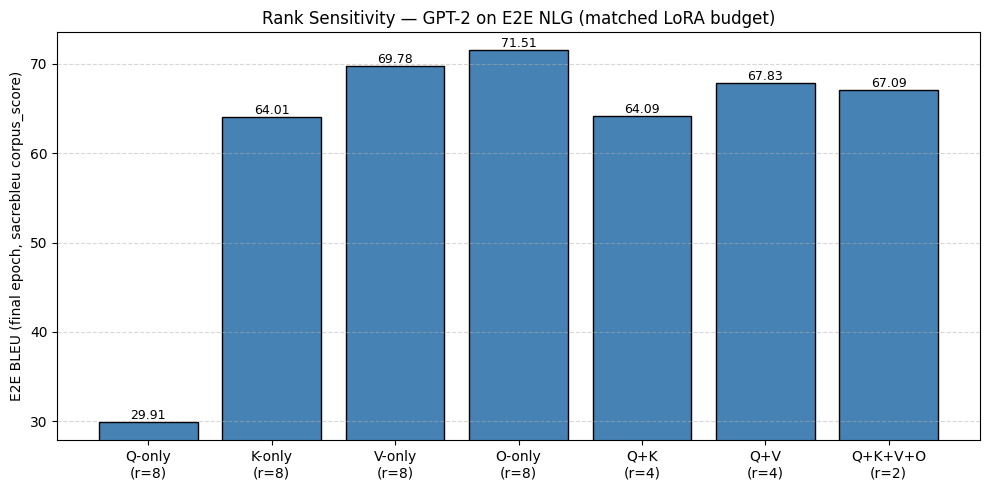

In [ ]:
import matplotlib.pyplot as plt


def _display_name_from_targets(targets):
    upper = [t.upper() for t in targets]
    if len(upper) == 1:
        return f"{upper[0]}-only"
    return "+".join(upper)


def _build_summary_from_disk(results_dir="results"):
    """Load most recent E2E rank-sweep result per LoRA-target combination."""
    by_targets = {}
    for p in sorted(Path(results_dir).glob("e2e_nlg__lora-*__*.json")):
        try:
            with p.open() as f:
                data = json.load(f)
        except (OSError, json.JSONDecodeError):
            continue
        bleus = data.get("eval_bleu_by_epoch") or []
        if not bleus or data.get("lora_r") is None:
            continue
        targets = tuple(data["model_tag"].replace("lora-", "").split("-"))
        # Sorted glob iterates by filename which ends with timestamp,
        # so later writes overwrite earlier ones for the same target set.
        by_targets[targets] = {
            "name": _display_name_from_targets(targets),
            "targets": targets,
            "rank": data["lora_r"],
            "final_bleu": bleus[-1],
            "results_path": str(p),
        }
    return list(by_targets.values())


try:
    summary = list(rank_sweep_summary)
    if not summary:
        raise NameError("rank_sweep_summary is empty")
except NameError:
    summary = _build_summary_from_disk()
    print(f"Loaded {len(summary)} runs from disk.")

if not summary:
    raise RuntimeError(
        "No rank-sweep results found. Run the rank sensitivity sweep cell above first."
    )

desired_order = ["Q-only", "K-only", "V-only", "O-only", "Q+K", "Q+V", "Q+K+V+O"]
summary_sorted = sorted(
    summary,
    key=lambda r: desired_order.index(r["name"]) if r["name"] in desired_order else 99,
)

names = [r["name"] for r in summary_sorted]
bleus = [r["final_bleu"] for r in summary_sorted]
ranks = [r["rank"] for r in summary_sorted]
labels = [f"{n}\n(r={k})" for n, k in zip(names, ranks)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, bleus, color="steelblue", edgecolor="black")
ax.set_ylabel("E2E BLEU (final epoch, sacrebleu corpus_score)")
ax.set_title("Rank Sensitivity \u2014 GPT-2 on E2E NLG (matched LoRA budget)")

ymin = max(0.0, min(bleus) - 2.0)
ax.set_ylim(ymin, max(bleus) + 2.0)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar, v in zip(bars, bleus):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v,
        f"{v:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)
fig_path = results_dir / f"rank_sensitivity_bleu_bar_{datetime.now().strftime('%Y%m%d-%H%M%S')}.png"
fig.savefig(fig_path, dpi=150)
print(f"Saved bar chart to {fig_path}")

plt.show()
